# 🎵 Análise de Tendências Globais do Spotify — 2026

**Autor:** Luccas Nunes  
**Dataset:** `spotify_global_trends_2026.csv` — 178 faixas do Top 200 Global  
**Cobertura:** 104 artistas, 15 países, 34 gêneros

---

## Estrutura da análise

1. **ETL** — Limpeza, normalização de países/gêneros e engenharia de features  
2. **Análise Exploratória (EDA)** — Top artistas, distribuição de streams, gêneros e origens  
3. **Análise Aprofundada** — Longevidade, viral score, tendências, power law e correlações

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib .pyplot as plt 
import matplotlib .ticker as mticker 
import seaborn as sns 
import warnings 
warnings .filterwarnings ('ignore')

plt .rcParams .update ({
'figure.facecolor':'#0D0D1A','axes.facecolor':'#12122A',
'axes.edgecolor':'#2A2A4A','axes.labelcolor':'#E2E8F0',
'xtick.color':'#8B9CC8','ytick.color':'#8B9CC8',
'text.color':'#E2E8F0','grid.color':'#1E1E3A',
'grid.linestyle':'--','grid.alpha':0.5 ,
'font.family':'sans-serif','font.size':11 ,
})

PURPLE ,CYAN ,AMBER ,ROSE ,SLATE ='#8B5CF6','#06B6D4','#F59E0B','#F43F5E','#8B9CC8'
print ('Bibliotecas carregadas ✓')

Bibliotecas carregadas ✓


## 1. ETL — Extração, Transformação e Carga

In [2]:
df =pd .read_csv ('spotify_global_trends_2026.csv')
print (f'Linhas brutas: {len (df ):,}')
df .head ()

Linhas brutas: 178


,track_name,artist_name,streams,stream_change,7day,genre,country,pos,days,viral_score,trend,popularity_category,longevity
0,SWIM,BTS,11273830,-3370522,25918182,K-Pop,KR,1,2,37192012,Falling,Trending,New
1,Body to Body,BTS,6815694,-4369341,18000729,K-Pop,KR,2,2,24816423,Falling,Trending,New
2,Babydoll,Dominic Fike,5733862,178968,36599831,Alternative Pop,Florida,3,119,42333693,Rising,Trending,Evergreen
3,Hooligan,BTS,5338608,-3396855,14074071,K-Pop,KR,4,2,19412679,Falling,Trending,New
4,FYA,BTS,5196767,-2873904,13267438,K-Pop,KR,5,2,18464205,Falling,Trending,New


In [3]:
# Normalização de países inconsistentes
country_fix ={'Florida':'US','Culiacán':'MX','Monterrey':'MX','England':'GB'}
df ['country']=df ['country'].replace (country_fix )

country_names ={
'US':'Estados Unidos','GB':'Reino Unido','KR':'Coreia do Sul',
'CA':'Canadá','PR':'Porto Rico','MX':'México',
'AU':'Austrália','CO':'Colômbia','SE':'Suécia',
'JM':'Jamaica','IT':'Itália','JP':'Japão',
'FR':'França','IE':'Irlanda','NO':'Noruega',
}
df ['country_name']=df ['country'].map (country_names ).fillna (df ['country'])

# Normalização de gêneros espúrios
genre_fix ={
'Billboard Hot 100':'Pop','Offizielle Charts':'Pop',
'Special Purpose Artist':'Other','Falcom':'Other',
'Dolby Atmos':'Other','Toronto':'Hip Hop',
}
df ['genre']=df ['genre'].replace (genre_fix )

# Engenharia de features
df ['streams_M']=df ['streams']/1_000_000 
df ['viral_score_M']=df ['viral_score']/1_000_000 
df ['week_streams_M']=df ['7day']/1_000_000 
df ['change_pct']=df ['stream_change']/(df ['streams']-df ['stream_change'])*100 
df ['streams_per_day']=df ['streams']/df ['days'].clip (lower =1 )
df ['is_rising']=(df ['trend']=='Rising').astype (int )

print (f'Artistas únicos  : {df ['artist_name'].nunique ()}')
print (f'Gêneros          : {df ['genre'].nunique ()}')
print (f'Países           : {df ['country'].nunique ()}')
print (f'Streams médios   : {df ['streams_M'].mean ():.2f}M')
print (f'% faixas em queda: {(df ['trend']=='Falling').mean ()*100 :.1f}%')

Artistas únicos  : 104
Gêneros          : 34
Países           : 15
Streams médios   : 2.09M
% faixas em queda: 77.0%


In [4]:
df .describe ().round (3 )

,streams,stream_change,7day,pos,days,viral_score,streams_M,viral_score_M,week_streams_M,change_pct,streams_per_day,is_rising
count,1.780000e+02,178.000,1.780000e+02,178.000,178.000,1.780000e+02,178.000,178.000,178.000,178.000,178.000,178.000
mean,2.093366e+06,-271987.669,1.244096e+07,96.124,536.275,1.453433e+07,2.093,14.534,12.441,-5.630,218545.257,0.230
std,1.277789e+06,752828.539,5.786175e+06,56.152,617.573,6.699639e+06,1.278,6.700,5.786,10.137,734510.495,0.422
min,1.191777e+06,-4369341.000,2.523194e+06,1.000,2.000,3.774959e+06,1.192,3.775,2.523,-42.040,399.905,0.000
25%,1.350050e+06,-126732.000,9.277907e+06,48.250,80.000,1.067544e+07,1.350,10.675,9.278,-6.803,2035.040,0.000
50%,1.590738e+06,-74084.500,1.080256e+07,96.500,346.500,1.257072e+07,1.591,12.571,10.803,-3.958,4899.150,0.000
75%,2.202585e+06,-5174.750,1.354278e+07,141.750,766.250,1.608216e+07,2.203,16.082,13.543,-0.284,23761.704,0.000
max,1.127383e+07,189999.000,3.659983e+07,200.000,3070.000,4.233369e+07,11.274,42.334,36.600,14.881,5636915.000,1.000


## 2. Análise Exploratória (EDA)

### 2.1 Top 15 artistas por streams totais

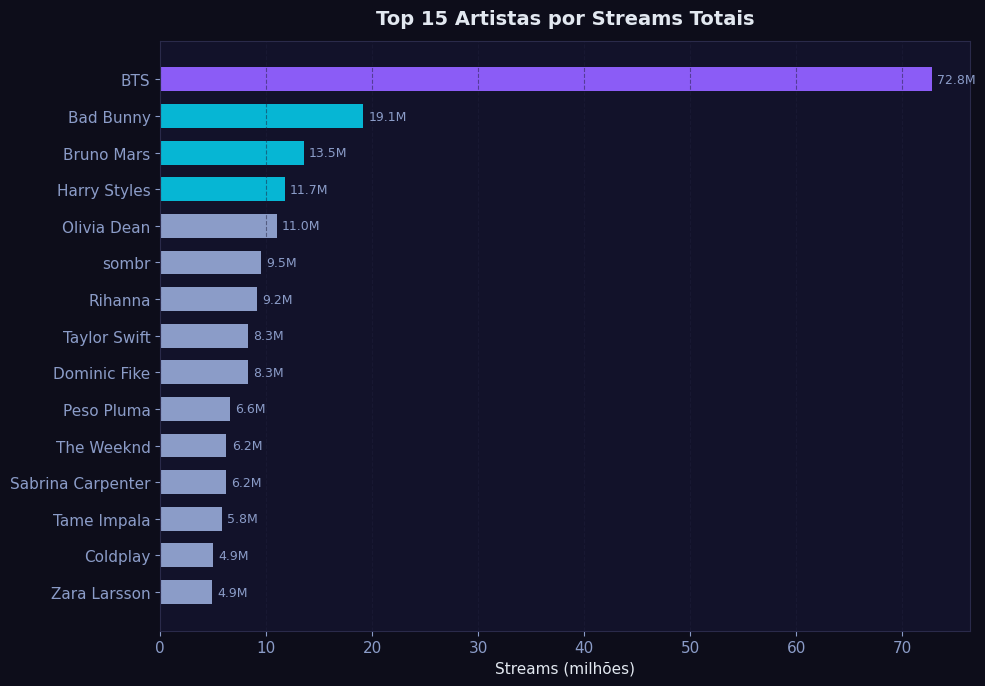

Insight: BTS lidera com 72.8M streams totais no período.


In [5]:
top_artists =df .groupby ('artist_name')['streams_M'].sum ().sort_values (ascending =True ).tail (15 )

fig ,ax =plt .subplots (figsize =(10 ,7 ))
colors =[PURPLE if v ==top_artists .max ()else (CYAN if v >=top_artists .quantile (0.75 )else SLATE )
for v in top_artists .values ]
bars =ax .barh (top_artists .index ,top_artists .values ,color =colors ,height =0.65 )
ax .set_title ('Top 15 Artistas por Streams Totais',fontsize =14 ,fontweight ='bold',pad =12 )
ax .set_xlabel ('Streams (milhões)');ax .grid (axis ='x')
for bar in bars :
    ax .text (bar .get_width ()+0.5 ,bar .get_y ()+bar .get_height ()/2 ,
    f'{bar .get_width ():.1f}M',va ='center',fontsize =9 ,color =SLATE )
plt .tight_layout ();plt .show ()

top =top_artists .idxmax ()
print (f'Insight: {top } lidera com {top_artists .max ():.1f}M streams totais no período.')

### 2.2 Distribuição de streams

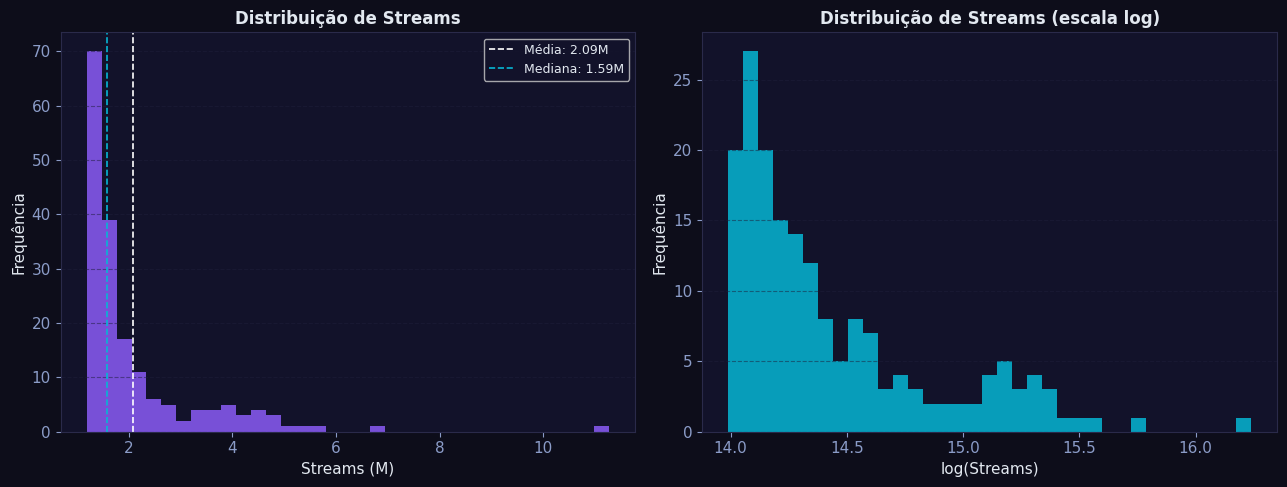

Insight: A média (2.09M) está bem acima da mediana (1.59M) — distribuição com cauda direita pesada.


In [6]:
fig ,axes =plt .subplots (1 ,2 ,figsize =(13 ,5 ))

axes [0 ].hist (df ['streams_M'],bins =35 ,color =PURPLE ,alpha =0.85 ,edgecolor ='none')
axes [0 ].axvline (df ['streams_M'].mean (),color ='white',linestyle ='--',linewidth =1.2 ,label =f'Média: {df ['streams_M'].mean ():.2f}M')
axes [0 ].axvline (df ['streams_M'].median (),color =CYAN ,linestyle ='--',linewidth =1.2 ,label =f'Mediana: {df ['streams_M'].median ():.2f}M')
axes [0 ].set_title ('Distribuição de Streams',fontsize =12 ,fontweight ='bold')
axes [0 ].set_xlabel ('Streams (M)');axes [0 ].set_ylabel ('Frequência');axes [0 ].legend (fontsize =9 );axes [0 ].grid (axis ='y')

axes [1 ].hist (np .log1p (df ['streams']),bins =35 ,color =CYAN ,alpha =0.85 ,edgecolor ='none')
axes [1 ].set_title ('Distribuição de Streams (escala log)',fontsize =12 ,fontweight ='bold')
axes [1 ].set_xlabel ('log(Streams)');axes [1 ].set_ylabel ('Frequência');axes [1 ].grid (axis ='y')

plt .tight_layout ();plt .show ()
print (f'Insight: A média ({df ['streams_M'].mean ():.2f}M) está bem acima da mediana ({df ['streams_M'].median ():.2f}M) — distribuição com cauda direita pesada.')

### 2.3 Streams por gênero

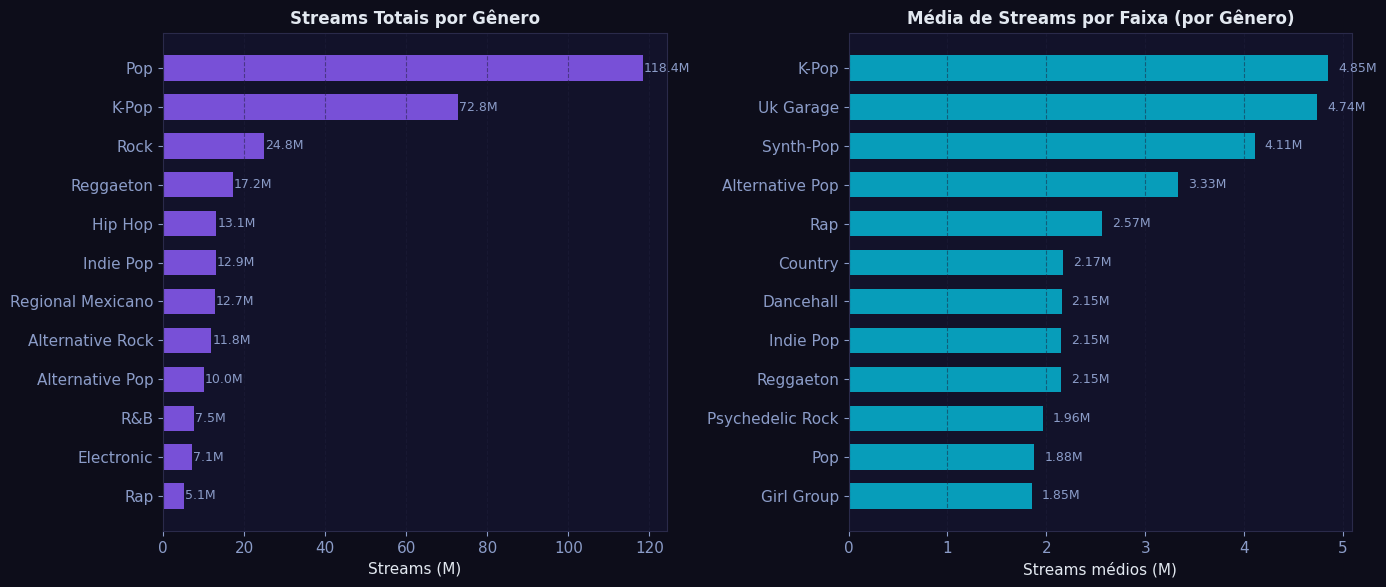

In [7]:
genre_streams =(df .groupby ('genre')['streams_M'].agg (['sum','mean','count']).sort_values ('sum',ascending =True ).tail (12 ))

fig ,axes =plt .subplots (1 ,2 ,figsize =(14 ,6 ))
bars =axes [0 ].barh (genre_streams .index ,genre_streams ['sum'],color =PURPLE ,alpha =0.85 ,height =0.65 )
axes [0 ].set_title ('Streams Totais por Gênero',fontsize =12 ,fontweight ='bold')
axes [0 ].set_xlabel ('Streams (M)');axes [0 ].grid (axis ='x')
for bar in bars :
    axes [0 ].text (bar .get_width ()+0.3 ,bar .get_y ()+bar .get_height ()/2 ,f'{bar .get_width ():.1f}M',va ='center',fontsize =9 ,color =SLATE )

genre_avg =df .groupby ('genre')['streams_M'].mean ().sort_values (ascending =True ).tail (12 )
bars2 =axes [1 ].barh (genre_avg .index ,genre_avg .values ,color =CYAN ,alpha =0.85 ,height =0.65 )
axes [1 ].set_title ('Média de Streams por Faixa (por Gênero)',fontsize =12 ,fontweight ='bold')
axes [1 ].set_xlabel ('Streams médios (M)');axes [1 ].grid (axis ='x')
for bar in bars2 :
    axes [1 ].text (bar .get_width ()+0.1 ,bar .get_y ()+bar .get_height ()/2 ,f'{bar .get_width ():.2f}M',va ='center',fontsize =9 ,color =SLATE )

plt .tight_layout ();plt .show ()

### 2.4 Faixas por país de origem do artista

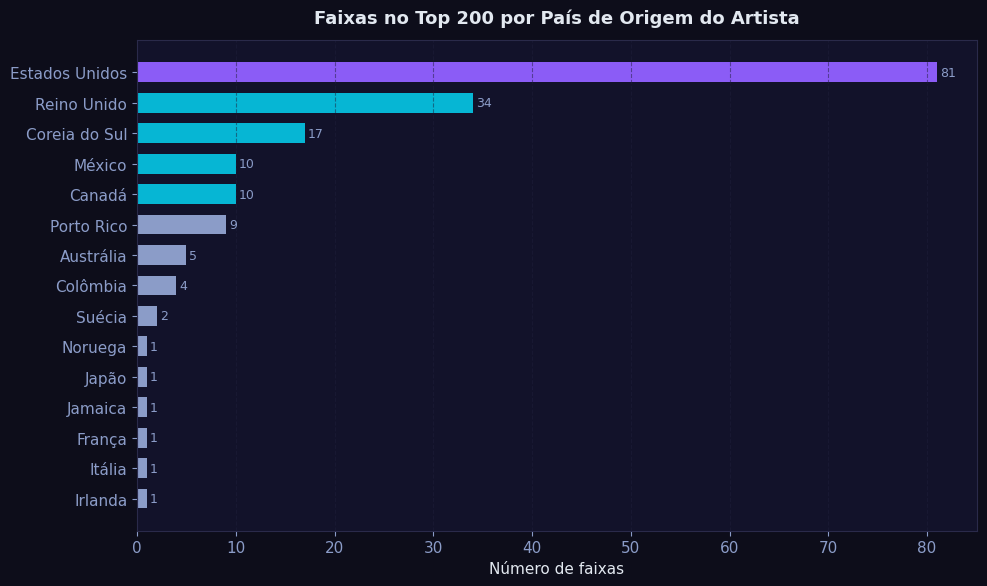

In [8]:
country_count =df .groupby ('country_name')['track_name'].count ().sort_values (ascending =True )

fig ,ax =plt .subplots (figsize =(10 ,6 ))
colors_c =[PURPLE if v ==country_count .max ()else (CYAN if v >=country_count .quantile (0.75 )else SLATE )
for v in country_count .values ]
bars =ax .barh (country_count .index ,country_count .values ,color =colors_c ,height =0.65 )
ax .set_title ('Faixas no Top 200 por País de Origem do Artista',fontsize =13 ,fontweight ='bold',pad =12 )
ax .set_xlabel ('Número de faixas');ax .grid (axis ='x')
for bar in bars :
    ax .text (bar .get_width ()+0.3 ,bar .get_y ()+bar .get_height ()/2 ,f'{int (bar .get_width ())}',va ='center',fontsize =9 ,color =SLATE )
plt .tight_layout ();plt .show ()

## 3. Análise Aprofundada

### 3.1 Longevidade × Streams

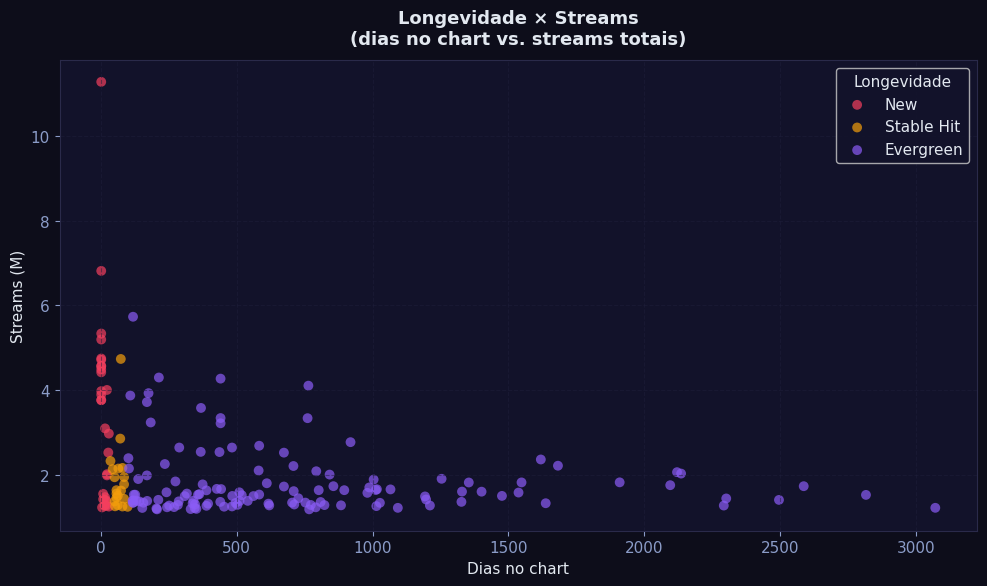

Streams médios por longevidade:
longevity
Evergreen     1.820507
New           3.393800
Stable Hit    1.889014


In [9]:
fig ,ax =plt .subplots (figsize =(10 ,6 ))
palette ={'New':ROSE ,'Stable Hit':AMBER ,'Evergreen':PURPLE }
for lng in ['New','Stable Hit','Evergreen']:
    subset =df [df ['longevity']==lng ]
    ax .scatter (subset ['days'],subset ['streams_M'],color =palette [lng ],alpha =0.7 ,s =50 ,label =lng ,edgecolors ='none')
ax .set_title ('Longevidade × Streams\n(dias no chart vs. streams totais)',fontsize =13 ,fontweight ='bold',pad =12 )
ax .set_xlabel ('Dias no chart');ax .set_ylabel ('Streams (M)')
ax .legend (title ='Longevidade');ax .grid (True )
plt .tight_layout ();plt .show ()

avg_by_lon =df .groupby ('longevity')['streams_M'].mean ()
print ('Streams médios por longevidade:')
print (avg_by_lon .to_string ())

### 3.2 Viral Score × Streams

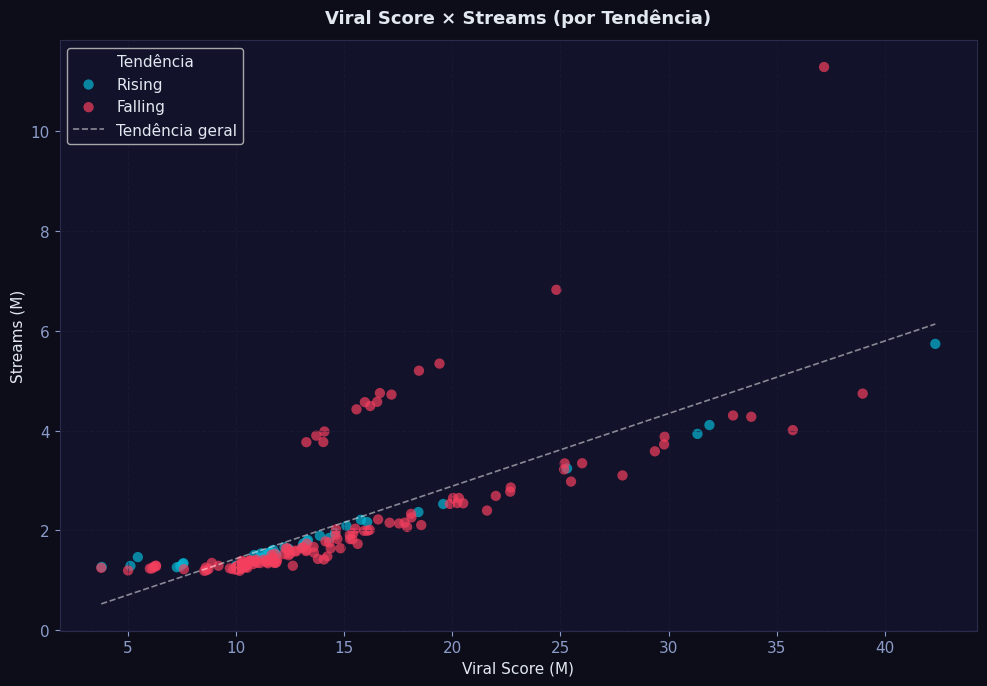

Correlação viral score × streams: 0.76


In [10]:
fig ,ax =plt .subplots (figsize =(10 ,7 ))
for trend ,color in [('Rising',CYAN ),('Falling',ROSE )]:
    subset =df [df ['trend']==trend ]
    ax .scatter (subset ['viral_score_M'],subset ['streams_M'],color =color ,alpha =0.7 ,s =55 ,label =trend ,edgecolors ='none')

z =np .polyfit (df ['viral_score_M'],df ['streams_M'],1 )
p =np .poly1d (z )
x_line =np .linspace (df ['viral_score_M'].min (),df ['viral_score_M'].max (),100 )
ax .plot (x_line ,p (x_line ),color ='white',linewidth =1.2 ,linestyle ='--',alpha =0.5 ,label ='Tendência geral')
ax .set_title ('Viral Score × Streams (por Tendência)',fontsize =13 ,fontweight ='bold',pad =12 )
ax .set_xlabel ('Viral Score (M)');ax .set_ylabel ('Streams (M)')
ax .legend (title ='Tendência');ax .grid (True )
plt .tight_layout ();plt .show ()

corr_val =df [['viral_score_M','streams_M']].corr ().iloc [0 ,1 ]
print (f'Correlação viral score × streams: {corr_val :.2f}')

### 3.3 Tendência por longevidade

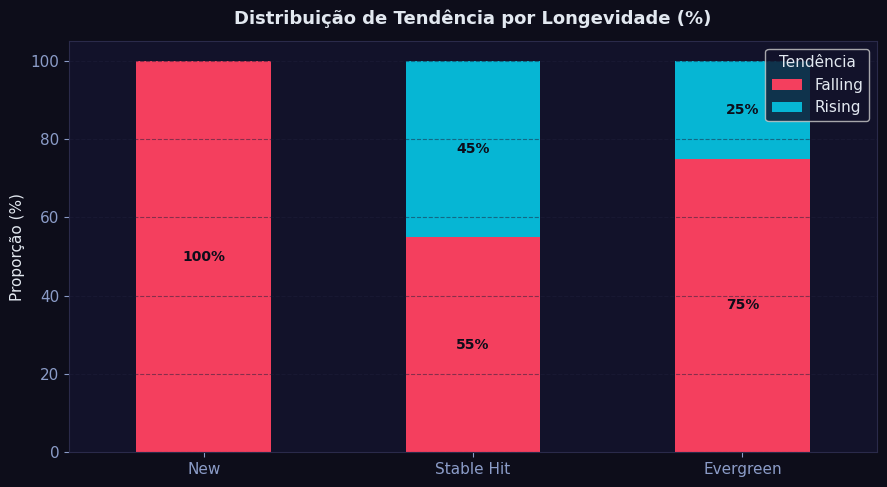

In [11]:
pivot =df .groupby (['longevity','trend']).size ().unstack (fill_value =0 )
pivot_pct =pivot .div (pivot .sum (axis =1 ),axis =0 )*100 
pivot_pct =pivot_pct .reindex (['New','Stable Hit','Evergreen'])

fig ,ax =plt .subplots (figsize =(9 ,5 ))
pivot_pct .plot (kind ='bar',stacked =True ,ax =ax ,color =[ROSE ,CYAN ],edgecolor ='none',width =0.5 )
ax .set_title ('Distribuição de Tendência por Longevidade (%)',fontsize =13 ,fontweight ='bold',pad =12 )
ax .set_xlabel ('');ax .set_ylabel ('Proporção (%)');ax .set_xticklabels (pivot_pct .index ,rotation =0 )
ax .legend (title ='Tendência',loc ='upper right');ax .grid (axis ='y')
for i ,(idx ,row )in enumerate (pivot_pct .iterrows ()):
    cumulative =0 
    for col ,color in zip (pivot_pct .columns ,[ROSE ,CYAN ]):
        val =row [col ]
        if val >5 :
            ax .text (i ,cumulative +val /2 ,f'{val :.0f}%',ha ='center',va ='center',fontsize =10 ,fontweight ='bold',color ='#0D0D1A')
        cumulative +=val 
plt .tight_layout ();plt .show ()

### 3.4 Posição no ranking × Streams (power law)

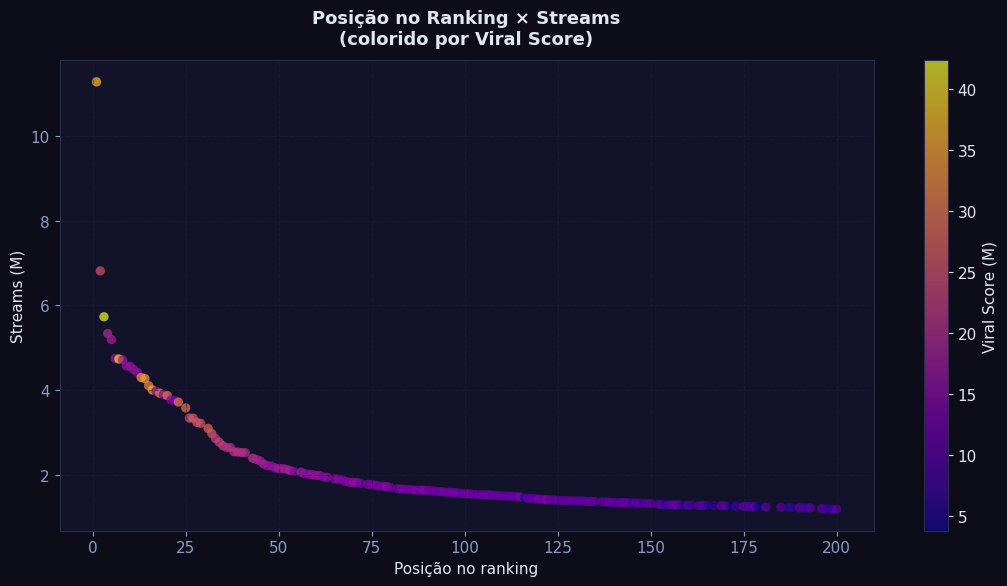

Streams médios Top 10   : 5.77M
Streams médios pos > 50 : 1.51M
Razão Top10 / resto     : 3.8x


In [12]:
fig ,ax =plt .subplots (figsize =(11 ,6 ))
sc =ax .scatter (df ['pos'],df ['streams_M'],c =df ['viral_score_M'],cmap ='plasma',alpha =0.7 ,s =45 ,edgecolors ='none')
cbar =fig .colorbar (sc ,ax =ax )
cbar .set_label ('Viral Score (M)',color ='#E2E8F0')
cbar .ax .yaxis .set_tick_params (color ='#E2E8F0')
plt .setp (cbar .ax .yaxis .get_ticklabels (),color ='#E2E8F0')
ax .set_title ('Posição no Ranking × Streams\n(colorido por Viral Score)',fontsize =13 ,fontweight ='bold',pad =12 )
ax .set_xlabel ('Posição no ranking');ax .set_ylabel ('Streams (M)');ax .grid (True )
plt .tight_layout ();plt .show ()

top10_avg =df [df ['pos']<=10 ]['streams_M'].mean ()
rest_avg =df [df ['pos']>50 ]['streams_M'].mean ()
print (f'Streams médios Top 10   : {top10_avg :.2f}M')
print (f'Streams médios pos > 50 : {rest_avg :.2f}M')
print (f'Razão Top10 / resto     : {top10_avg /rest_avg :.1f}x')

### 3.5 Correlação entre variáveis

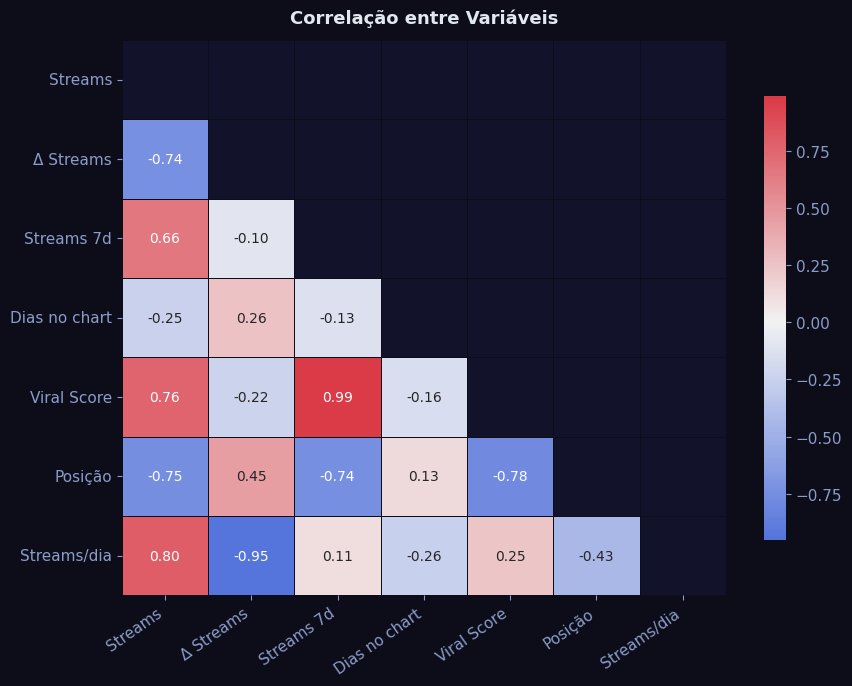

In [13]:
corr_cols =['streams_M','stream_change','week_streams_M','days','viral_score_M','pos','streams_per_day']
corr =df [corr_cols ].corr ()
col_labels ={'streams_M':'Streams','stream_change':'Δ Streams','week_streams_M':'Streams 7d',
'days':'Dias no chart','viral_score_M':'Viral Score','pos':'Posição','streams_per_day':'Streams/dia'}

fig ,ax =plt .subplots (figsize =(9 ,7 ))
mask =np .triu (np .ones_like (corr ,dtype =bool ))
cmap =sns .diverging_palette (260 ,10 ,as_cmap =True )
sns .heatmap (corr ,mask =mask ,cmap =cmap ,center =0 ,annot =True ,fmt ='.2f',
linewidths =0.5 ,linecolor ='#0D0D1A',ax =ax ,annot_kws ={'size':10 },cbar_kws ={'shrink':0.8 })
ax .set_title ('Correlação entre Variáveis',fontsize =13 ,fontweight ='bold',pad =12 )
ax .set_xticklabels ([col_labels .get (c ,c )for c in corr .columns ],rotation =35 ,ha ='right')
ax .set_yticklabels ([col_labels .get (c ,c )for c in corr .index ],rotation =0 )
plt .tight_layout ();plt .show ()

### 3.6 Boxplot de streams por longevidade e popularidade

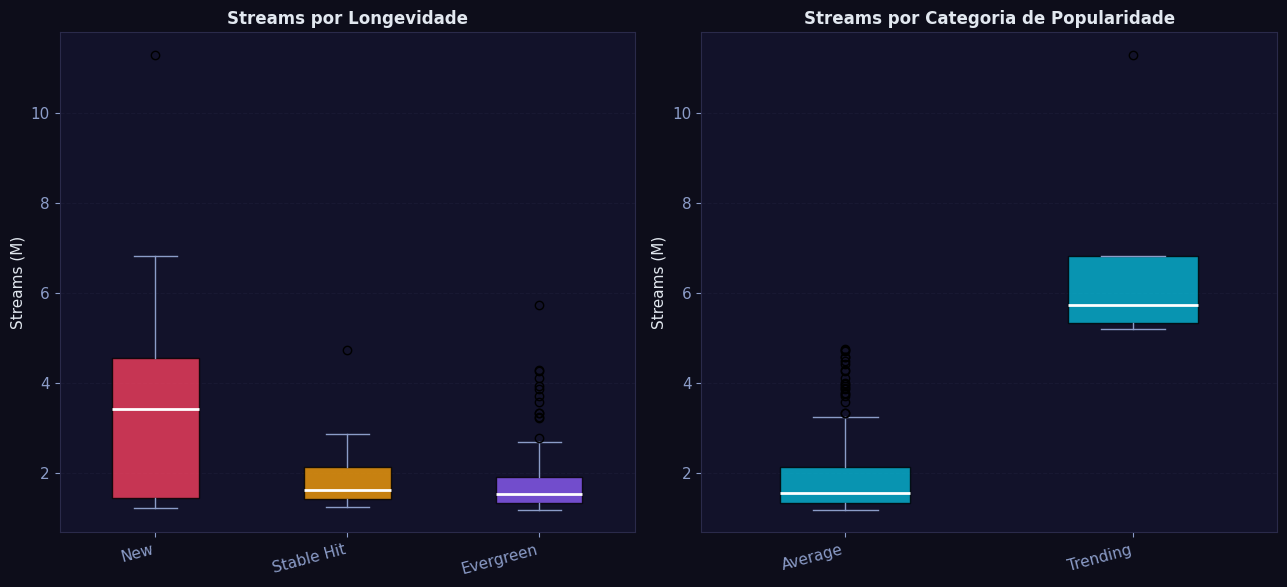

In [14]:
fig ,axes =plt .subplots (1 ,2 ,figsize =(13 ,6 ))
order_lon =['New','Stable Hit','Evergreen']
palette_lon ={'New':ROSE ,'Stable Hit':AMBER ,'Evergreen':PURPLE }

for i ,(col ,title ,order ,palette )in enumerate ([
('longevity','Streams por Longevidade',order_lon ,palette_lon ),
('popularity_category','Streams por Categoria de Popularidade',None ,{k :CYAN for k in df ['popularity_category'].unique ()}),
]):
    data_groups =df .groupby (col )['streams_M'].apply (list )
    if order :data_groups =data_groups .reindex (order )
    keys =list (data_groups .index )
    values =[data_groups [k ]for k in keys ]
    bp =axes [i ].boxplot (values ,patch_artist =True ,widths =0.45 ,medianprops ={'color':'white','linewidth':2 })
    for patch ,key in zip (bp ['boxes'],keys ):
        patch .set_facecolor (palette .get (key ,SLATE ));patch .set_alpha (0.8 )
    for element in ['whiskers','caps','fliers']:
        for item in bp [element ]:item .set (color =SLATE ,linewidth =1 )
    axes [i ].set_xticklabels (keys ,rotation =15 ,ha ='right')
    axes [i ].set_title (title ,fontsize =12 ,fontweight ='bold')
    axes [i ].set_ylabel ('Streams (M)');axes [i ].grid (axis ='y')

plt .tight_layout ();plt .show ()

## 4. Principais Insights

| # | Insight | Detalhe |
|---|---------|----------|
| 1 | **BTS domina o período** | 72.8M streams totais — mais que o dobro do 2º colocado |
| 2 | **EUA concentram 45% das faixas** | Hegemonia cultural clara no Top 200 Global |
| 3 | **77% das faixas em queda** | Mercado em fase de acomodação — poucos lançamentos em ascensão |
| 4 | **Faixas novas decaem rápido** | "New" entra com alto volume e queda acentuada logo nas primeiras semanas |
| 5 | **Viral Score e Streams têm correlação de 0.76** | Alta viralidade é forte indicador de streams — mas não garante tendência de alta |
| 6 | **Power law clara no ranking** | Top 10 gera streams médios ~4x maiores que posições acima de 50 |